# Init

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax import numpy as jnp
from iaif.mouse_simple import plot_results
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from sklearn import linear_model
import matplotlib as mpl
import pickle

jax.config.update("jax_enable_x64", True)

# Setting

In [4]:
# Load targets
targets = pd.read_csv("./data/targets.csv", header=0).values[:, :2]
start_target = np.array([0.   , 0.003])

# Load data

In [5]:
run_name = "iaif_standard" #
nplans = 1000
max_steps = 100
expected_num_repeats = 10

folder = f"./data"
input_folder = f"{folder}/simulations/{run_name}"
output_folder = f"{folder}/plots/{run_name}/plots_{nplans}"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [25]:
# Walk path and load files (can be slow)
summary_file = f"{folder}/{run_name}_{nplans}_results_summary.csv"
if os.path.exists(summary_file):
    df = pd.read_csv(summary_file)
    print("Loaded existing results summary.")
else:
    data_rows = []
    trigger_x = {}
    for file in os.listdir(input_folder):
        print(file)
        if file.endswith(".pkl"):
            if nplans is not None:
                if f"nplans_{nplans}_" not in file:
                    continue
            target = file.split("target_")[1].split("_")[0]
            repeat = file.split("rep_")[1].split(".pkl")[0]
            # Load existing dataframe
            with open(os.path.join(input_folder, file), "rb") as f:
                data_dict = pickle.load(f)
            ic_efe_threshold = data_dict['ic_efe_threshold']
            ic_timesteps = data_dict['ic_timesteps']
            ic_pred_error_trigger = data_dict['ic_pred_error']
            ic_div_threshold = data_dict['ic_div_threshold']
            comp_time = data_dict['computation_time']
            xx = data_dict['xx']
            oo = data_dict['oo']
            timesteps_inside_target = sum(np.array([o[1] for o in oo]) > 0.9)

            data_row = {'target': target, 'repeat': repeat, 'ic_efe_threshold': ic_efe_threshold,  'ic_div_threshold': ic_div_threshold, 'num_replanning': len(ic_timesteps) if ic_timesteps is not None else len(xx)-1, 'trial_steps': len(xx), 'timesteps_inside_target': timesteps_inside_target, 'computation_time': comp_time}
            # Flag as unfinished due to NaN in belief
            data_row['unfinished'] =  data_row['trial_steps'] < max_steps
            data_rows.append(data_row)

    df = pd.DataFrame(data_rows)
    df.to_csv(summary_file, index=False)


Loaded existing results summary.


In [26]:
# Make sure target is int
df['target'] = df['target'].astype(int)

# Count unfinished trials
num_unfinished = df['unfinished'].sum()
print(f"Number of unfinished trials: {num_unfinished}")

# Remove unfinished trials from dataframe
df = df[df['unfinished'] == False]

Number of unfinished trials: 0


In [28]:
df

,target,repeat,ic_efe_threshold,ic_div_threshold,num_replanning,trial_steps,timesteps_inside_target,computation_time,unfinished
0,9,8,NaN,40.0,61,101,77,23.796620,False
1,1,2,NaN,10.0,74,101,76,24.582139,False
2,1,3,1.0,30.0,89,101,80,37.250819,False
3,9,6,1.0,10.0,96,101,87,32.444114,False
4,1,8,NaN,30.0,50,101,76,22.116302,False
...,...,...,...,...,...,...,...,...,...
1915,7,4,NaN,10.0,81,101,76,25.626023,False
1916,3,3,NaN,60.0,44,101,82,21.754803,False
1917,3,2,1.0,70.0,69,101,89,30.097560,False
1918,4,5,NaN,60.0,50,101,73,22.457451,False


In [31]:
df[(df["ic_div_threshold"].isna()) & (df["ic_efe_threshold"].isna())]["computation_time"].describe()

count    120.000000
mean      27.443199
std        0.493693
min       26.782959
25%       27.260943
50%       27.365753
75%       27.457770
max       31.898480
Name: computation_time, dtype: float64

In [9]:
# Replace nans in thresholds with -1.0
df['ic_efe_threshold'] = df['ic_efe_threshold'].fillna(-1.0)
df['ic_div_threshold'] = df['ic_div_threshold'].fillna(-1.0)

# round ic_efe_threshold and ic_div_threshold to 3 decimal places 
df['ic_efe_threshold'] = df['ic_efe_threshold'].round(3)
df['ic_div_threshold'] = df['ic_div_threshold'].round(3)


In [10]:
# Check if results are complete
PRAGMATIC_THRESHOLDS = df['ic_efe_threshold'].unique() #np.hstack([np.arange(0.0, 0.9, 0.1), np.arange(0.90, 0.99, 0.02,), np.arange(0.99, 1.011, 0.002), np.arange(1.02, 1.1, 0.02), np.arange(1.1, 2.1, 0.1)])
KL_THRESHOLDS = df['ic_div_threshold'].unique() 


TARGETS = df['target'].unique().tolist()
expected_num_thresholds = PRAGMATIC_THRESHOLDS.shape[0]
results_complete = True
missing_info = []
incomplete_targets = []
for threshold in PRAGMATIC_THRESHOLDS:
    for kl_threshold in KL_THRESHOLDS:
        for target_id in TARGETS:
            if np.isnan(threshold):
                subset = df[df['ic_efe_threshold'].isnull()]
            else:   
                subset = df[df['ic_efe_threshold'] == threshold]
            if np.isnan(kl_threshold):
                subset = subset[subset['ic_div_threshold'].isnull()]
            else:
                subset = subset[subset['ic_div_threshold'] == kl_threshold]
            subset = subset[subset['target'] == target_id]
            actual_num_repeats = subset.shape[0]
            if actual_num_repeats < expected_num_repeats:
                results_complete = False
                missing_info.append((threshold, kl_threshold, target_id, expected_num_repeats - actual_num_repeats))
                if target_id not in incomplete_targets:
                    incomplete_targets.append(target_id)

if not results_complete:
    print("Missing results:")
    for info in missing_info:
        print(f"EFE Threshold {info[0]}, KL threshold {info[1]}, target {info[2]}: missing {info[3]} runs")
    # Remove incomplete results from dataframe
    if len(missing_info) > 0:
        for (threshold, kl_threshold, target_id, missing_count) in missing_info:
            print(f"Removing incomplete threshold {threshold}, KL threshold {kl_threshold}, target {target_id} with {missing_count} missing runs")
            df = df[~((df['ic_efe_threshold'] == threshold) & (df['ic_div_threshold'] == kl_threshold))]
else:
    print("Results are complete.")

Results are complete.


# Target Plot

In [11]:
TARGETS_Sorted = [int(t) for t in TARGETS]
TARGET_IDs = {t: np.round(np.log2((np.abs(targets[int(t)][0])/targets[int(t)][1])+1), 2) for t in TARGETS}
TARGETS_Sorted.sort()
IDs_sorted = np.unique(list(TARGET_IDs.values()))
IDs_sorted.sort()

# Add Index of Difficulty to each row
df['index_of_difficulty'] = [TARGET_IDs[target] for target in df['target']]

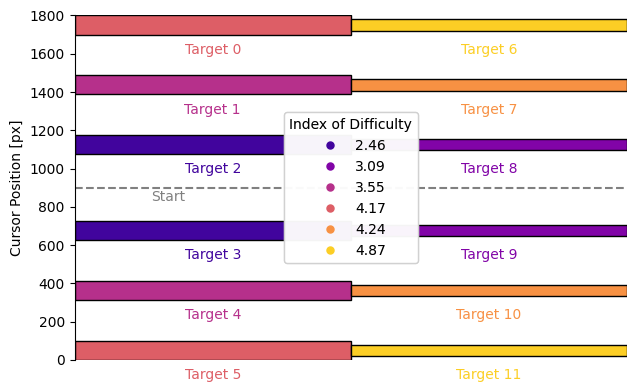

In [12]:
colors_large = mpl.colormaps['cool'](np.linspace(0, 1, 6))
colors_small = mpl.colormaps['copper'](np.linspace(0, 1, 6))
colors = mpl.colormaps['plasma'](np.linspace(0.1, 0.9, len(IDs_sorted)))
ID_colors = {IDs_sorted[i]: colors[i] for i in range(len(IDs_sorted))}

target_colors = {target_nr: ID_colors[TARGET_IDs[target_nr]] for target_nr in TARGETS_Sorted}

# Plot targets for verification
fig, ax = plt.subplots(figsize=(1.618*4,4))
for i, target_nr in enumerate(TARGETS_Sorted):
    target = targets[int(target_nr)]
    rect = plt.Rectangle((0.5 * (i//6), (target[0]-target[1])*1000+900), 0.5, target[1]*2*1000, linewidth=1, fill=True, facecolor=target_colors[target_nr], edgecolor='black', alpha=1)
    ax.add_patch(rect)
    ax.text(0.25 + (i//6) *0.5, (target[0]-0.15)*1000+900, f'Target {target_nr}', ha='center', color=target_colors[target_nr])

ax.hlines(900, xmin=0, xmax=1, colors='gray', linestyles='dashed')
ax.text(0.2 , 900-70, 'Start', ha='right', color='gray')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1800)
ax.set_xticks([])
ax.set_ylabel("Cursor Position [px]")

# # Create new legend for target IDs and colors
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    

target_legend_elements = [Line2D([0], [0], marker='o', linestyle='None', color=ID_colors[id_single],
                                 label=f'{id_single:.2f}', markersize=5) for id_single in IDs_sorted]
target_legend = ax.legend(handles=target_legend_elements, title='Index of Difficulty')   
ax.add_artist(target_legend)

ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{output_folder}/IC_Target_Locations.pdf", dpi=300)

# Settings for Plots

In [13]:
# Fix hue order
df = df.sort_values(by=['ic_efe_threshold', 'ic_div_threshold'], ascending=[False, False])
hue_order = sorted(df["ic_div_threshold"].dropna().unique(), reverse=False)
hue_order.remove(-1.)
hue_order.append(-1.)
df["ic_div_threshold"] = pd.Categorical(df["ic_div_threshold"], categories=hue_order, ordered=True)
palette = sns.color_palette("YlOrBr", len(hue_order))

In [14]:
# Separate Data
df_baseline = df[(df['ic_div_threshold'] == -1.) & (df['ic_efe_threshold'] == -1.)]
df_wo_baseline = df[~((df['ic_div_threshold'] == -1.) & (df['ic_efe_threshold'] == -1.))]
df_limited = df_wo_baseline[df_wo_baseline['ic_efe_threshold'].isin([-1.0, 1.0])]
df_only_div = df_limited[df_limited['ic_efe_threshold'] == -1.0]
df_only_div = df_only_div[df_only_div['ic_div_threshold'] != -1.0]
df_efe_only = df[(df['ic_div_threshold'] == -1.) & (df['ic_efe_threshold'] == 1.)]
df_combined = df_limited[df_limited['ic_efe_threshold'] != -1.0]
df_combined = df_combined[df_combined['ic_div_threshold'] != -1.0]


In [15]:
# Print all mean values
for ic_efe_threshold in df['ic_efe_threshold'].unique():
    for ic_div_threshold in df['ic_div_threshold'].unique():
        subset = df[(df['ic_efe_threshold'] == ic_efe_threshold) & (df['ic_div_threshold'] == ic_div_threshold)]
        mean_replanning = subset['num_replanning'].mean()
        mean_comp_time = subset['computation_time'].mean()
        mean_success_rate = subset['timesteps_inside_target'].mean()
        print(f"Mean values for EFE Threshold {ic_efe_threshold}, DIV Threshold {ic_div_threshold}:")
        print(f"  Mean Number of Replannings: {mean_replanning:.3f}")
        print(f"  Mean Computation Time: {mean_comp_time:.3f}s")
        print(f"  Mean Time on Target [%] (Timesteps Inside Target): {mean_success_rate:.3f}")

Mean values for EFE Threshold 1.0, DIV Threshold 70.0:
  Mean Number of Replannings: 84.683
  Mean Computation Time: 32.373s
  Mean Time on Target [%] (Timesteps Inside Target): 77.275
Mean values for EFE Threshold 1.0, DIV Threshold 60.0:
  Mean Number of Replannings: 85.658
  Mean Computation Time: 32.265s
  Mean Time on Target [%] (Timesteps Inside Target): 77.092
Mean values for EFE Threshold 1.0, DIV Threshold 50.0:
  Mean Number of Replannings: 86.583
  Mean Computation Time: 32.323s
  Mean Time on Target [%] (Timesteps Inside Target): 76.917
Mean values for EFE Threshold 1.0, DIV Threshold 40.0:
  Mean Number of Replannings: 87.492
  Mean Computation Time: 32.263s
  Mean Time on Target [%] (Timesteps Inside Target): 76.758
Mean values for EFE Threshold 1.0, DIV Threshold 30.0:
  Mean Number of Replannings: 88.775
  Mean Computation Time: 32.191s
  Mean Time on Target [%] (Timesteps Inside Target): 76.550
Mean values for EFE Threshold 1.0, DIV Threshold 20.0:
  Mean Number of Rep

# Trigger Events

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3135590/2084507454.py:16: SyntaxWarning: invalid escape sequence '\e'
  ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')
/tmp/ipykernel_3135590/2084507454.py:18: SyntaxWarning: invalid escape sequence '\e'
  boxpl.legend_.set_title("$\epsilon_{Div}$")


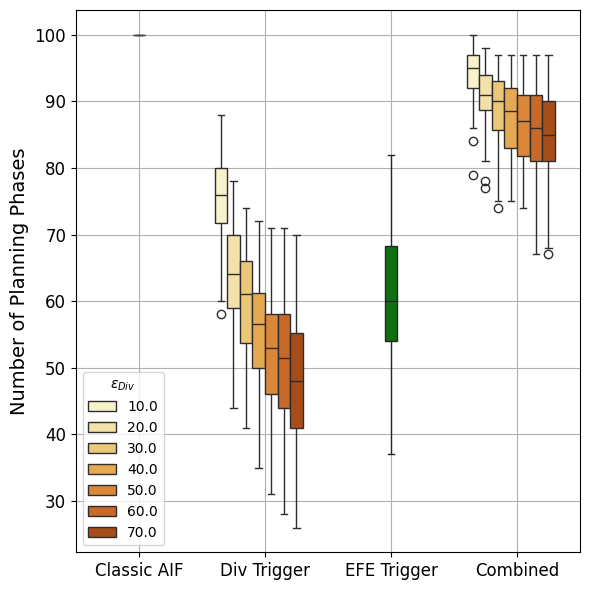

In [16]:
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(data=df_baseline, x=0.0, y='num_replanning',ax=ax, color='blue',  width=1/10) 
sns.boxplot(data=df_only_div, x='ic_efe_threshold', y='num_replanning', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette, legend=False) 
sns.boxplot(data=df_efe_only, x=2.0, y='num_replanning',ax=ax, color='green', width=1/10)
boxpl = sns.boxplot(data=df_combined, x='ic_efe_threshold', y='num_replanning', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette) 

# Remove legend entry for -1.0
handles, labels_text = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels_text):
    if label != "-1.0":
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')

boxpl.legend_.set_title("$\epsilon_{Div}$")
boxpl.legend_.set_loc('lower left')

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)

# Change x ticks to Without EFE Trigger and With EFE Trigger
ax.set_xticks([0.0, 1.0, 2.0, 3.0])
ax.set_xticklabels(["Classic AIF", "Div Trigger", "EFE Trigger", "Combined"])
ax.set_xlabel(None)
ax.set_ylabel("Number of Planning Phases")

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/IC_vs_Num_IC_Triggers.pdf")


# Computation Time

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3135590/3771006923.py:9: SyntaxWarning: invalid escape sequence '\e'
  boxpl.legend_.set_title("$\epsilon_{Div}$")
/tmp/ipykernel_3135590/3771006923.py:20: SyntaxWarning: invalid escape sequence '\e'
  ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')


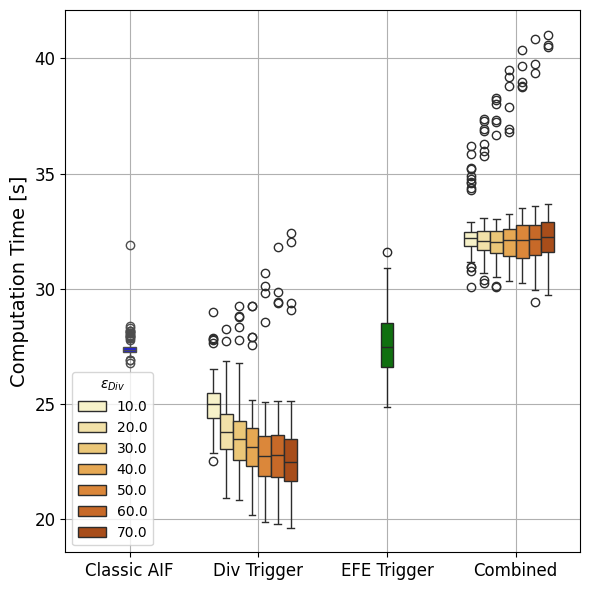

In [17]:
fig, ax = plt.subplots(figsize=(6,6))


sns.boxplot(data=df_baseline, x=0.0, y='computation_time',ax=ax, color='blue',  width=1/10)
sns.boxplot(data=df_only_div, x='ic_efe_threshold', y='computation_time', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette, legend=False) 
sns.boxplot(data=df_efe_only, x=2.0, y='computation_time',ax=ax, color='green', width=1/10)
boxpl = sns.boxplot(data=df_combined, x='ic_efe_threshold', y='computation_time', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette)

boxpl.legend_.set_title("$\epsilon_{Div}$")
boxpl.legend_.set_loc('lower left')

# Remove legend entry for -1.0
handles, labels_text = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels_text):
    if label != "-1.0":
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)


# Change x ticks
ax.set_xticks([0.0, 1.0, 2.0, 3.0])
ax.set_xticklabels(["Classic AIF", "Div Trigger", "EFE Trigger", "Combined"])
ax.set_xlabel(None)
ax.set_ylabel("Computation Time [s]")

plt.grid(True) 
plt.tight_layout()

plt.savefig(f"{output_folder}/ic_efe_threshold_vs_Computation_Time.pdf", dpi=300)

# Successful Trials

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3135590/1872356500.py:10: SyntaxWarning: invalid escape sequence '\e'
  boxpl.legend_.set_title("$\epsilon_{Div}$")
/tmp/ipykernel_3135590/1872356500.py:21: SyntaxWarning: invalid escape sequence '\e'
  ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')


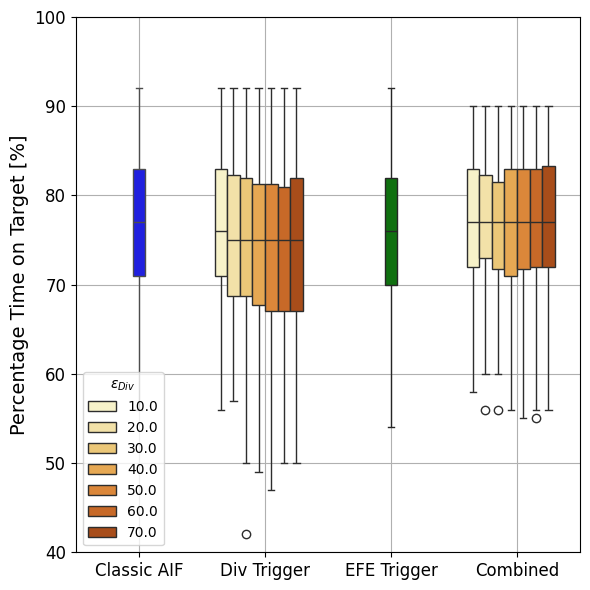

In [18]:
# Plot Time on Target [%]
fig, ax = plt.subplots(figsize=(6,6))

sns.boxplot(data=df_baseline, x=0.0, y='timesteps_inside_target',ax=ax, color='blue',  width=1/10)
sns.boxplot(data=df_only_div, x='ic_efe_threshold', y='timesteps_inside_target', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette, legend=False)
sns.boxplot(data=df_efe_only, x=2.0, y='timesteps_inside_target',ax=ax, color='green', width=1/10)
boxpl = sns.boxplot(data=df_combined, x='ic_efe_threshold', y='timesteps_inside_target', hue='ic_div_threshold', ax=ax, hue_order=hue_order, palette=palette) 

# Change legend for kl threshold -1.0 to "No"
boxpl.legend_.set_title("$\epsilon_{Div}$")
boxpl.legend_.set_loc('lower left')

# Remove legend entry for -1.0
handles, labels_text = ax.get_legend_handles_labels()
filtered_handles = []
filtered_labels = []
for handle, label in zip(handles, labels_text):
    if label != "-1.0":
        filtered_handles.append(handle)
        filtered_labels.append(label)
ax.legend(filtered_handles, filtered_labels, title="$\epsilon_{Div}$", loc='lower left')

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)

ax.set_xticks([0.0, 1.0, 2.0, 3.0])
ax.set_xticklabels(["Classic AIF", "Div Trigger", "EFE Trigger", "Combined"])
ax.set_xlabel(None)
ax.set_ylabel("Percentage Time on Target [%]")

ax.set_ylim(40, 100)

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/Success_Rate.pdf")

## Performance vs. Success

<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3135590/1847429256.py:44: SyntaxWarning: invalid escape sequence '\e'
  label='IAIF - Div Trigger only ($\epsilon_{Div}=30.0$)', markersize=markersize)


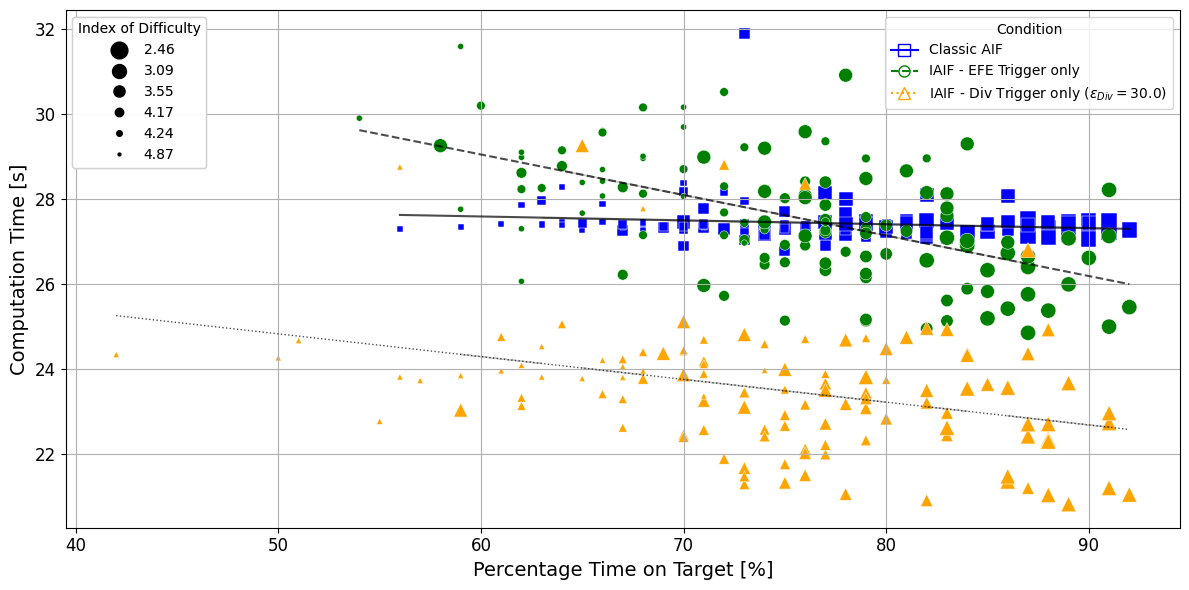

In [19]:
# Plot Time on Target [%] against computation time color by ic_efe_threshold
fig, ax = plt.subplots(figsize=(12,6))

df.sort_values(by=['target', 'ic_efe_threshold', 'ic_div_threshold'], ascending=[True, False, False], inplace=True)

df_baseline = df[(df['ic_efe_threshold']==-1.0)&(df['ic_div_threshold']==-1.0)]
df_aif = df[(df['ic_efe_threshold']==1.0)&(df['ic_div_threshold']==-1.0)]
df_div = df[(df['ic_efe_threshold']==-1.0)&(df['ic_div_threshold']==30.0)]
targets_in_legend = df_baseline['target'].unique()

markers = [(3,1,0),(4,1,0),(5,1,0),(6,1,0),(7,1,0),(8,1,0)]
markersize=8
sizes = [120,100,80,60,40,20]

scatter = sns.scatterplot(data=df_baseline, x='timesteps_inside_target', y='computation_time', ax=ax, size='index_of_difficulty',  marker='s', color='blue', legend=False, sizes=sizes)
scatter = sns.scatterplot(data=df_aif, x='timesteps_inside_target', y='computation_time', ax=ax, size='index_of_difficulty',   marker='o', color='green', legend=False, sizes=sizes)
scatter = sns.scatterplot(data=df_div, x='timesteps_inside_target', y='computation_time', ax=ax, size='index_of_difficulty',  marker='^', color='orange', legend=True, sizes=sizes)

# Add regression lines for each condition
x = df_baseline['timesteps_inside_target'].to_numpy().reshape(-1, 1)
y = df_baseline['computation_time'].to_numpy().reshape(-1, 1)
regr_baseline = linear_model.LinearRegression()
regr_baseline.fit(x, y)
sns.lineplot({'x':x.reshape(-1,), 'y':regr_baseline.predict(x).reshape(-1,)}, x='x',y='y', color='black', linestyle='-', ax=ax,alpha=0.7)

x = df_aif['timesteps_inside_target'].to_numpy().reshape(-1, 1)
y = df_aif['computation_time'].to_numpy().reshape(-1, 1)
regr_aif = linear_model.LinearRegression()
regr_aif.fit(x, y)
sns.lineplot({'x':x.reshape(-1,), 'y':regr_aif.predict(x).reshape(-1,)}, x='x',y='y',  color='black', linestyle='--',ax=ax, alpha=0.7)

x = df_div['timesteps_inside_target'].to_numpy().reshape(-1, 1)
y = df_div['computation_time'].to_numpy().reshape(-1, 1)
regr_div = linear_model.LinearRegression()
regr_div.fit(x, y)
sns.lineplot({'x':x.reshape(-1,), 'y':regr_div.predict(x).reshape(-1,)}, x='x',y='y', linestyle=':', color='black', linewidth=1, ax=ax, alpha=0.7)

legend_elements = [
    Line2D([0], [0], linestyle='-', color='blue', marker='s', fillstyle='none',
           label='Classic AIF', markersize=markersize),
    Line2D([0], [0], linestyle='--', color='green', marker='o', fillstyle='none',
           label='IAIF - EFE Trigger only', markersize=markersize),
    Line2D([0], [0], linestyle=':', color='orange', marker='^', fillstyle='none',
           label='IAIF - Div Trigger only ($\epsilon_{Div}=30.0$)', markersize=markersize)
]
condition_legend = ax.legend(handles=legend_elements, title='Condition', loc='upper right')
ax.add_artist(condition_legend)

# Create new legend for target IDs 
target_legend_elements = [Line2D([0], [0], marker='o', linestyle='None', color="black",
                                 label=f'{id_single:.2f}', markersize=sizes[i]/10) for i,id_single in enumerate(IDs_sorted)]
target_legend = ax.legend(handles=target_legend_elements, title='Index of Difficulty', loc='upper left')   
ax.add_artist(target_legend)

# Increase Label and ticks font size
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
ax.tick_params(axis='both', which='major', labelsize=12)

ax.set_ylabel("Computation Time [s]")
ax.set_xlabel("Percentage Time on Target [%]")

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/IC_Time_Steps_Inside_Target_vs_Computation_Time_Scatter_limited.pdf")  

# Single Trajectory

## IAIF

Rows: [['pos', 'pos']]


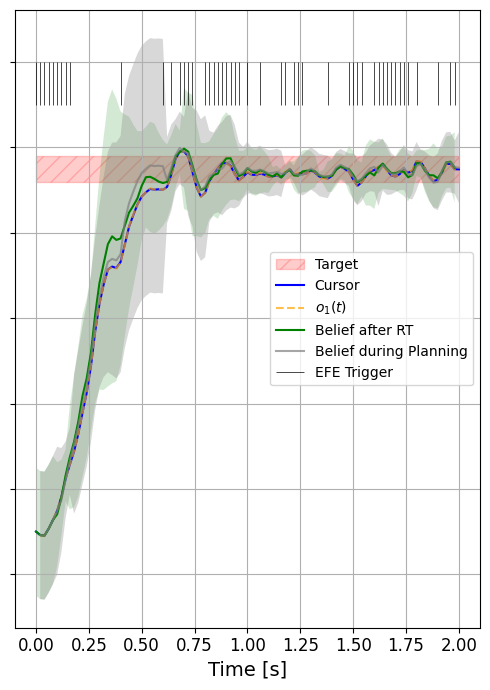

In [20]:
ic_efe_threshold = 1.00
ic_div_threshold = None
target_id = 6
repeat = 1

# Load example data for plotting
file = f"{input_folder}/target_{target_id}_{f'nplans_{nplans}_pred_{ic_div_threshold}_' if nplans is not None else ''}prag_{ic_efe_threshold}_rep_{repeat}.pkl"
with open(file, "rb") as f:
    data_dict = pickle.load(f)
dt = data_dict['dt']
xx = data_dict['xx']
oo = data_dict['oo']
bb = data_dict['bb']
aa = data_dict['aa']
aa_applied = data_dict['aa_applied']
lll = data_dict['lll']
nefe_plan = data_dict['nefe_plan']
pragmatic_plan = data_dict['pragmatic_plan']
info_gain_plan = data_dict['info_gain_plan']
nefess = data_dict['nefess']
pragmatics = data_dict['pragmatics']
info_gains = data_dict['info_gains']
buttons = data_dict['buttons']
ic_timesteps = data_dict['ic_timesteps']
bb_predicted = data_dict['bb_predicted']
bb_after_rt = data_dict['bb_after_rt']
params = data_dict['params']
ic_div_threshold = params['ic_div_threshold']
ic_efe_threshold = params['ic_efe_threshold']

numsteps = len(xx)-1

rows = []
rows.append(['pos', 'pos'])

figsize_x = 5
fig, ax = plt.subplot_mosaic(rows, figsize=(figsize_x,7*len(rows)))
plot_axes = ['pos']


xx_new = []
for x in xx:
    x0 = (x[0]*1000 + 900) # Convert to pixels
    x1 = x[1]*1000
    x2 = x[2]*1000 + 900 # Convert to pixels
    x3 = x[3]*1000 # Convert to pixels
    x_new = jnp.array([x0, x1, x2, x3])
    xx_new.append(x_new)

oo_new = [o.at[0].set(o[0]*1000 + 900) for o in oo] # Convert to pixels

bb_new = []
for b in bb:
    b0 = b[0].at[0].set(b[0][0]*1000 + 900) # Convert to pixels
    b0 = b0.at[2].set(b[0][2]*1000 + 900) # Convert to pixels
    b0 = b0.at[3].set(b[0][1]*1000) # Convert to pixels
    b1 = b[1].at[0,0].set(b[1][0,0]*1000**2) # Convert to pixels
    bb_new.append((b0, b1))

buttons[1] = [buttons[1][0]*1000+900, buttons[1][1]*1000]


fig, ax, t = plot_results(dt, xx_new, oo_new, bb_new, aa, aa_applied, lll, nefe_plan, pragmatic_plan, info_gain_plan, nefess, pragmatics, info_gains, hide_belief=True, belief_button=False, fig=fig, ax=ax, plot_axes=plot_axes)
std_mult = 3

# Belief after reaction time
mean = [b[0][0]*1000 + 900 for b in bb_after_rt]
var = [b[1][0, 0]*1000**2 for b in bb_after_rt]
ax['pos'].plot(t[:-1], mean, label=['Belief after RT'], color='green')
ribbons = np.array([[mean[i] - std_mult * np.sqrt(var[i]), mean[i] + std_mult * np.sqrt(var[i])] for i in range(len(mean))])
ax['pos'].fill_between(t[:-1], ribbons[:, 0], ribbons[:, 1], facecolor="green", alpha=1 / 6)

# # Plot predicted belief trajectory
predicted_means = [bb_predicted[i][0][0]*1000+900 for i in bb_predicted if i <= len(xx)-1]
ax['pos'].plot(t[1:], predicted_means, color='grey', label='Belief during Planning', alpha=0.7)
predicted_covs = [bb_predicted[i][1][0,0]*1000**2 for i in bb_predicted if i <= numsteps]
ribbons = np.array([[predicted_means[i] - std_mult * np.sqrt(predicted_covs[i]), predicted_means[i] + std_mult * np.sqrt(predicted_covs[i])] for i in range(len(predicted_means))])
ax['pos'].fill_between(t[1:], ribbons[:, 0], ribbons[:, 1], facecolor="grey", alpha=0.3)

# IC timesteps
if len(ic_timesteps)>0:
    ax['pos'].vlines(np.array(ic_timesteps)*dt, ymin=1900, ymax=2000, color='black', label='EFE Trigger', alpha=1.0, linewidth=0.5)

ic_efe_threshold = params['ic_efe_threshold']
ax['pos'].legend(loc='center right')

# get ylims
ylims = ax['pos'].get_ylim()

ax['pos'].set_yticklabels([])
ax['pos'].set_ylabel('')


# Increase Label and ticks font size
ax['pos'].xaxis.label.set_size(14)
ax['pos'].yaxis.label.set_size(14)
ax['pos'].tick_params(axis='both', which='major', labelsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/Single_Trial_prag_{ic_efe_threshold}_kl_{ic_div_threshold}_target_{target_id}_rep_{repeat}.pdf")

## AIF Baseline

Rows: [['pos', 'pos']]


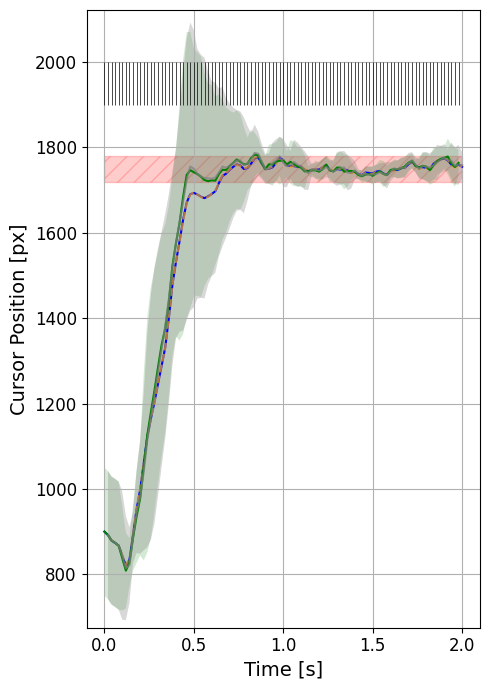

In [21]:
# Standard AIF baseline
ic_efe_threshold = None
ic_div_threshold = None

# Load example data for plotting
file = f"{input_folder}/target_{target_id}_{f'nplans_{nplans}_pred_{ic_div_threshold}_' if nplans is not None else ''}prag_{ic_efe_threshold}_rep_{repeat}.pkl"
with open(file, "rb") as f:
    data_dict = pickle.load(f)
dt = data_dict['dt']
xx = data_dict['xx']
oo = data_dict['oo']
bb = data_dict['bb']
aa = data_dict['aa']
aa_applied = data_dict['aa_applied']
lll = data_dict['lll']
nefe_plan = data_dict['nefe_plan']
pragmatic_plan = data_dict['pragmatic_plan']
info_gain_plan = data_dict['info_gain_plan']
nefess = data_dict['nefess']
pragmatics = data_dict['pragmatics']
info_gains = data_dict['info_gains']
buttons = data_dict['buttons']
ic_timesteps = data_dict['ic_timesteps']
bb_predicted = data_dict['bb_predicted']
bb_after_rt = data_dict['bb_after_rt']
params = data_dict['params']
ic_div_threshold = params['ic_div_threshold']
ic_efe_threshold = params['ic_efe_threshold']

numsteps = len(xx)-1

rows = []
rows.append(['pos', 'pos'])

fig, ax = plt.subplot_mosaic(rows, figsize=(figsize_x,7*len(rows)))
plot_axes = ['pos']

xx_new = []
for x in xx:
    x0 = (x[0]*1000 + 900) # Convert to pixels
    x1 = x[1]*1000
    x2 = x[2]*1000 + 900# Convert to pixels
    x3 = x[3]*1000 # Convert to pixels
    x_new = jnp.array([x0, x1, x2, x3])
    xx_new.append(x_new)

oo_new = [o.at[0].set(o[0]*1000 + 900) for o in oo] # Convert to pixels

bb_new = []
for b in bb:
    b0 = b[0].at[0].set(b[0][0]*1000 + 900) # Convert to pixels
    b0 = b0.at[2].set(b[0][2]*1000 + 900) # Convert to pixels
    b0 = b0.at[3].set(b[0][1]*1000) # Convert to pixels
    b1 = b[1].at[0,0].set(b[1][0,0]*1000**2) # Convert to pixels
    bb_new.append((b0, b1))


buttons[1] = [buttons[1][0]*1000+900, buttons[1][1]*1000]

fig, ax, t = plot_results(dt, xx_new, oo_new, bb_new, aa, aa_applied, lll, nefe_plan, pragmatic_plan, info_gain_plan, nefess, pragmatics, info_gains, hide_belief=True, fig=fig, ax=ax, plot_axes=plot_axes)
std_mult = 3

# Belief after reaction time
mean = [b[0][0]*1000 + 900 for b in bb_after_rt]
var = [b[1][0, 0]*1000**2 for b in bb_after_rt]
ax['pos'].plot(t[:-1], mean, label=['belief after RT'], color='green')
ribbons = np.array([[mean[i] - std_mult * np.sqrt(var[i]), mean[i] + std_mult * np.sqrt(var[i])] for i in range(len(mean))])
ax['pos'].fill_between(t[:-1], ribbons[:, 0], ribbons[:, 1], facecolor="green", alpha=1 / 6)

# # Plot predicted belief trajectory
predicted_means = [bb_predicted[i][0][0]*1000+900 for i in bb_predicted if i <= len(xx)-1]
ax['pos'].plot(t[1:], predicted_means, color='grey', label='Belief during Planning', alpha=0.7)
predicted_covs = [bb_predicted[i][1][0,0]*1000**2 for i in bb_predicted if i <= numsteps]
ribbons = np.array([[predicted_means[i] - std_mult * np.sqrt(predicted_covs[i]), predicted_means[i] + std_mult * np.sqrt(predicted_covs[i])] for i in range(len(predicted_means))])
ax['pos'].fill_between(t[1:], ribbons[:, 0], ribbons[:, 1], facecolor="grey", alpha=0.3)


# IC timesteps (Baseline - trigger every step)
baseline_trigger = [i for i in range(numsteps)]
ax['pos'].vlines(np.array([baseline_trigger])*dt,  ymin=1900, ymax=2000, color='black', alpha=1.0, linewidth=0.5)

ax['pos'].legend(loc='center right')

# Remove legend
ax['pos'].get_legend().remove()
ax['pos'].set_ylim(ylims)

ax['pos'].set_ylabel("Cursor Position [px]")

# Increase Label and ticks font size
ax['pos'].xaxis.label.set_size(14)
ax['pos'].yaxis.label.set_size(14)
ax['pos'].tick_params(axis='both', which='major', labelsize=12)

plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_folder}/Single_Trial_prag_{ic_efe_threshold}_kl_{ic_div_threshold}_target_{target_id}_rep_{repeat}.pdf")